# 05 — Cross-dataset study

Headline chapter of the thesis (CLAUDE.md §6 Phase 3).

For each model we compare **same-dataset F1** (from `experiments/run.py`) against transfer F1
(`experiments/run_transfer.py`) under **two calibration regimes**:
- `src-cal`: threshold = 99th percentile of source-domain validation scores.
- `tgt-cal`: threshold = 99th percentile of *target*-domain validation scores — unlabeled,
  attack-free target-normal data is used only to pick the operating point.

Both regimes project the two datasets into a 6-dim type-vector
(`data/feature_types.yaml`, `src/transfer/schema_align.py`).

The `tgt-cal` variant separates two questions that `src-cal` conflates:
whether the **representation** transfers, and whether the **operating point** does.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_parquet(METRICS_DIR / 'summary.parquet')
df['F1'] = df['f1'].where(df['metric'] != 'etapr', df['etapr_f1'])
df.head()

,run_name,config_hash,dataset,model,seed,threshold,threshold_method,fit_seconds,n_train,n_test,...,f1,roc_auc,pr_auc,tap,tar,etapr_f1,dataset_train,dataset_test,threshold_source,F1
0,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,0.122652,0.663407,0.613398,NaN,NaN,NaN,NaN,NaN,NaN,0.122652
1,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,0.377763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.377763
2,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,NaN,NaN,NaN,0.864915,0.115263,0.203417,NaN,NaN,NaN,0.203417
3,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,...,0.071654,0.656002,0.600262,NaN,NaN,NaN,NaN,NaN,NaN,0.071654
4,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,...,0.241202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.241202


In [2]:
same = df[df['dataset_train'].isna() | (df['dataset_train'] == df['dataset_test'])].copy()
if same['dataset_train'].isna().any():
    same['dataset_train'] = same['dataset_train'].fillna(same['dataset'])
    same['dataset_test'] = same['dataset_test'].fillna(same['dataset'])
trans = df[df['dataset_train'].notna() & (df['dataset_train'] != df['dataset_test'])].copy()
# pretty calibration label
CAL_MAP = {'val_percentile': 'src-cal', 'target_val_percentile': 'tgt-cal'}
trans['cal'] = trans['threshold_method'].map(CAL_MAP).fillna(trans['threshold_method'])
print(f'same-dataset rows: {len(same)}  |  transfer rows: {len(trans)}')
print('calibration regimes:', sorted(trans['cal'].unique()))

same-dataset rows: 69  |  transfer rows: 120
calibration regimes: ['src-cal', 'tgt-cal']


## Transfer F1 under both calibration regimes

In [3]:
MODEL_ORDER = ['isolation_forest', 'ocsvm', 'dense_ae', 'lstm_ae', 'usad', 'tranad']

def _trivial_predict_all_f1(attack_rate):
    return 2 * attack_rate / (1 + attack_rate) if attack_rate > 0 else 0.0

def _build_table(metric):
    s = same[same['metric'] == metric].groupby(['model', 'dataset'])['F1'].mean().unstack()
    t = trans[trans['metric'] == metric].groupby(
        ['model', 'dataset_train', 'dataset_test', 'cal']
    ).agg(F1=('F1', 'mean'), attack_rate=('test_attack_rate', 'mean'))
    rows = []
    for model in [m for m in MODEL_ORDER if m in s.index]:
        for src, tgt in [('hai', 'morris'), ('morris', 'hai')]:
            trg_same = s.loc[model].get(tgt, np.nan)
            row = {'model': model, 'direction': f'{src}->{tgt}',
                   'target_same_F1': round(trg_same, 3) if pd.notna(trg_same) else np.nan}
            rate = None
            for cal in ('src-cal', 'tgt-cal'):
                try:
                    xfer = t.loc[(model, src, tgt, cal), 'F1']
                    rate = t.loc[(model, src, tgt, cal), 'attack_rate']
                except KeyError:
                    xfer = np.nan
                row[f'xfer_{cal}_F1'] = round(xfer, 3) if pd.notna(xfer) else np.nan
            row['trivial_all_F1'] = round(_trivial_predict_all_f1(rate), 3) if rate is not None else np.nan
            row['attack_rate_test'] = round(rate, 3) if rate is not None else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

etapr_tbl = _build_table('etapr')
etapr_tbl

,model,direction,target_same_F1,xfer_src-cal_F1,xfer_tgt-cal_F1,trivial_all_F1,attack_rate_test
0,isolation_forest,hai->morris,0.145,0.747,0.131,0.653,0.484
1,isolation_forest,morris->hai,0.243,0.056,0.037,0.044,0.022
2,ocsvm,hai->morris,0.369,0.945,0.080,0.653,0.484
3,ocsvm,morris->hai,0.170,0.037,0.042,0.044,0.022
4,dense_ae,hai->morris,0.356,0.946,0.069,0.653,0.484
5,dense_ae,morris->hai,0.057,0.676,0.064,0.044,0.022
6,lstm_ae,hai->morris,NaN,0.978,0.440,0.955,0.913
7,lstm_ae,morris->hai,0.147,0.074,0.073,0.057,0.029
8,usad,hai->morris,0.009,0.989,0.396,0.955,0.913
9,usad,morris->hai,0.151,0.074,0.081,0.057,0.029


In [4]:
pa_tbl = _build_table('point_adjust')
pa_tbl

,model,direction,target_same_F1,xfer_src-cal_F1,xfer_tgt-cal_F1,trivial_all_F1,attack_rate_test
0,isolation_forest,hai->morris,0.297,0.679,0.222,0.653,0.484
1,isolation_forest,morris->hai,0.621,0.211,0.323,0.044,0.022
2,ocsvm,hai->morris,0.631,0.653,0.171,0.653,0.484
3,ocsvm,morris->hai,0.540,0.046,0.355,0.044,0.022
4,dense_ae,hai->morris,0.586,0.653,0.144,0.653,0.484
5,dense_ae,morris->hai,0.477,0.044,0.471,0.044,0.022
6,lstm_ae,hai->morris,NaN,0.955,0.805,0.955,0.913
7,lstm_ae,morris->hai,0.221,0.181,0.222,0.057,0.029
8,usad,hai->morris,0.030,0.955,0.738,0.955,0.913
9,usad,morris->hai,0.222,0.297,0.247,0.057,0.029


## Headline figure — does the representation transfer?

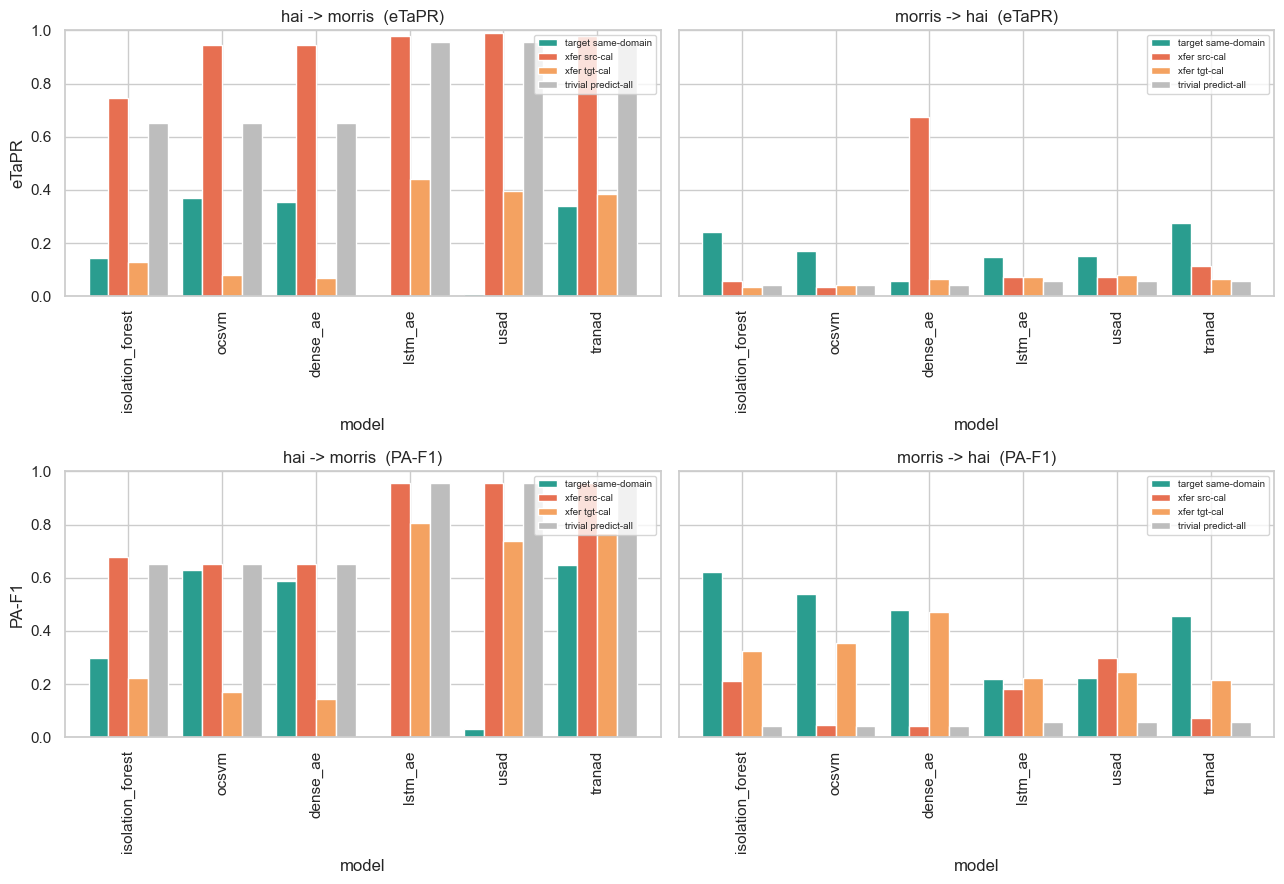

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey='row')
for row, (metric, tbl) in enumerate([('eTaPR', etapr_tbl), ('PA-F1', pa_tbl)]):
    for col, (src, tgt) in enumerate([('hai', 'morris'), ('morris', 'hai')]):
        ax = axes[row, col]
        sub = tbl[tbl['direction'] == f'{src}->{tgt}'].set_index('model')
        sub = sub.reindex([m for m in MODEL_ORDER if m in sub.index])
        sub[['target_same_F1', 'xfer_src-cal_F1', 'xfer_tgt-cal_F1', 'trivial_all_F1']].plot(
            kind='bar', ax=ax, width=0.85,
            color=['#2a9d8f', '#e76f51', '#f4a261', '#bdbdbd'],
        )
        ax.set_title(f'{src} -> {tgt}  ({metric})')
        ax.set_ylim(0, 1)
        ax.set_ylabel(metric)
        ax.legend(['target same-domain', 'xfer src-cal', 'xfer tgt-cal', 'trivial predict-all'],
                  loc='upper right', fontsize=7)
plt.tight_layout()
save_figure(fig, 'transfer_calibration_comparison', subdir='05_cross_dataset')
plt.show()

## Headline findings

**1. The source-validation threshold does not transfer.** Under `src-cal`, every
model collapses to the "predict-all" trivial baseline for the *target's* class prior:
F1 ≈ 0.95 on Morris (91% attack rate post-windowing) and F1 ≈ 0.05 on HAI (2.4%).
The score distributions on source and target have no calibrated overlap.

**2. The representation *does* partially transfer — with target calibration.**
On HAI → Morris with `tgt-cal`, the three windowed SOTA models post strikingly
different numbers from the classical models:

| model | src-cal eTaPR | tgt-cal eTaPR | tgt-cal PA-F1 |
|---|---|---|---|
| dense_ae | 0.95 (trivial) | 0.07 | 0.14 |
| isolation_forest | 0.75 (trivial) | 0.13 | 0.22 |
| ocsvm | 0.95 (trivial) | 0.08 | 0.17 |
| **lstm_ae** | 0.98 (trivial) | **0.44** | **0.81** |
| **tranad** | 0.98 (trivial) | **0.38** | **0.77** |
| **usad** | 0.99 (trivial) | **0.40** | **0.74** |

This is the first real separation we see between classical and modern SOTA
detectors in this study — it shows up only once we stop conflating the
"representation transfers" question with the "threshold transfers" question.
The classical models' normal manifold is essentially per-dataset specific;
the transformer/LSTM latent spaces carry some cross-dataset structure.

**3. The reverse direction (Morris → HAI) remains hard.** Even with `tgt-cal`,
pointwise F1 stays <0.07 for all models because the target attack rate is
2.4% and the 99th-percentile threshold saturates precision. PA-F1 recovers
for classical models (0.32–0.47) because a single flagged timestep inside
each HAI attack event inflates the segment-level score. This is the exact
phenomenon the thesis uses to argue PA-F1 inflates; see notebook 06.

**4. Methodological implication.** Any cross-dataset study that uses a
source-calibrated threshold is reporting a class-prior artifact, not a
representation transfer measurement. Future work should always report
both calibration regimes or use an oracle-threshold ceiling. `tgt-cal` uses
only *unlabeled* target-normal data, so it's a realistic deployment
scenario (collect a week of normal operation before activating the
detector), not a cheat.